In [56]:
import numpy as np
import sys
from diversity.diversty import Diversity

In [57]:
from option1.env import Environment

# Define environment, inputs and outputs

## Parameters for simulation

In [116]:
simu_params = {
"min_address" : 0,
"max_address" : 19,
"max_instructions" : 100,
}
max_cycle = 60 #Maximum cycle in simulation
step = 10 # Window size to get information,  observation vectors will contain "max_intructions"/step performance counters reports

In [117]:
environment = Environment(step = step,max_instructions=simu_params["max_instructions"])

## Inputs

In [118]:
from option1.codegeneration import Address_Management 

In [119]:
addr_management = Address_Management(**simu_params)
address_x=5
code_generation_method = lambda: addr_management.generate_instruction_sequence(address_x = address_x)

## Ouputs

In [120]:
instructions = code_generation_method()
environment(instructions)

{'cache_hit_l1': {0: 6, 1: 2, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0},
 'cache_hit_l2': {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0},
 'cache_misses_l1': {0: 4,
  1: 0,
  2: 0,
  3: 0,
  4: 0,
  5: 0,
  6: 0,
  7: 0,
  8: 0,
  9: 0},
 'cache_misses_l2': {0: 0,
  1: 0,
  2: 0,
  3: 0,
  4: 0,
  5: 0,
  6: 0,
  7: 0,
  8: 0,
  9: 0},
 'time_core0': 49}

# IMGEP parameters

In [121]:
from option1.history import History
from option1.OptimizationPolicy import OptimizationPolicykNN
from option1.distance import DistanceMethod
from option1.mutation import MutationInstructions
from option1.mix_interleaving import Mix_sequences_interleaved
from option1.goal_generation import GoalGenerator
from option1.imgep import run_imgep,Randomexploration

In [122]:
k = 2 #Number of neighbors in goal achievement strategy
N = 10000 #Number of imgep iterations
capacity = N #History capacity
N_init = 2000 #Number of warming iterations. Longer warming stages allows better results with respect to a random exploration
num_mutations = 3 #Nb of mutations in goal achievement strategy
#address X to work on
address_x = 5
print_freq = 100 #print iteration step every print_freq

## Distance function

In [123]:
def distance_function(goal,features,weights=None):
    x = goal
    v = x-features
    if type(weights)!=type(None):
        out = np.sum(weights*(v**2),axis=1)
    else:
        out = np.sum(v**2,axis=1)
    return out

# IMGEP without using cycle time information

In [175]:
history = History(capacity=capacity,unused=['time_core0'])

#goal generation
goalgenerator = GoalGenerator(history)

#optimization policy models

mutation_method = MutationInstructions(num_mutations,**simu_params)
mixing_method   = Mix_sequences_interleaved(max_cycle)
max_tab = np.ones((4*simu_params["max_instructions"]//step,))*10
weights = 1.0/max_tab
distance_method = DistanceMethod(distance_function,weights=weights)

### Run imgep

In [176]:
run_imgep(N_init=N_init,
        N=N,
        capacity=capacity,
        k=k,
        environment = environment,
        history=history,
        code_generation_method = code_generation_method,
        goal_generator=goalgenerator,
        distance_method=distance_method,
        mutation_method=mutation_method,
        mixing_method=mixing_method,
        )

initilization
run random exploration


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:03<00:00, 530.05it/s]


start of imgep


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:35<00:00, 225.18it/s]

39.30352282524109


### Run random exploration for comparison

In [177]:
history_rand = History(capacity=capacity,unused=['time_core0'])
random_explorer = Randomexploration(N,environment,code_generation_method,history_rand)
random_explorer()

run random exploration


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:17<00:00, 561.36it/s]


### Evaluation

In [178]:
dim_out = history_rand.numpy_view.shape[1]
min_tab = np.zeros((dim_out,))
max_tab = np.ones((dim_out,))*10
#max_tab[-1] = 300
diversity_ = Diversity(min_tab = min_tab,
                        max_tab = max_tab,
                        num_bins = 10)
diversity_imgep_list = [diversity_(history.as_tab()[:print_freq*step]) for step in range(N//print_freq)]
diversity_random_list = [diversity_(history_rand.as_tab()[:print_freq*step]) for step in range(N//print_freq)]

In [179]:
import matplotlib.pyplot as plt

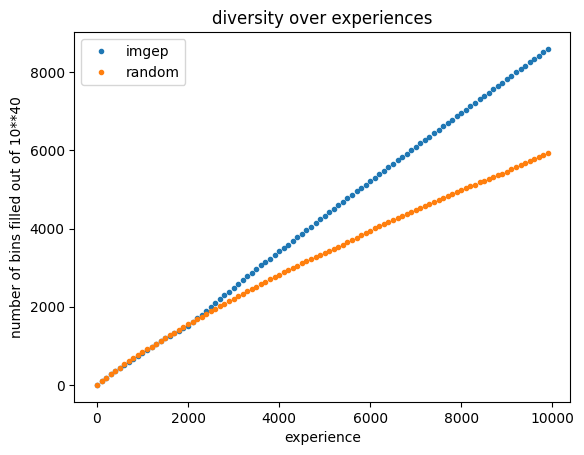

In [180]:
plt.plot(range(0,N,print_freq),diversity_imgep_list,'.',label="imgep")
plt.plot(range(0,N,print_freq),diversity_random_list,'.',label="random")
plt.legend()
plt.title('diversity over experiences')
plt.xlabel('experience')
plt.ylabel(f'number of bins filled out of 10**{dim_out}')
plt.show()

In [181]:
history_rand.memory_observation.keys()

dict_keys(['cache_hit_l1', 'cache_hit_l2', 'cache_misses_l1', 'cache_misses_l2', 'time_core0'])

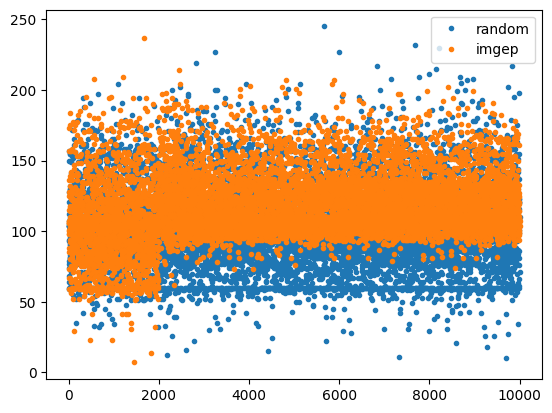

In [182]:
plt.figure()
plt.plot(range(N),history_rand.memory_observation['time_core0'],'.',label='random')
plt.plot(range(N),history.memory_observation['time_core0'],'.',label='imgep')
plt.legend()

# IMGEP when exploting and observing time

In [183]:
history = History(capacity=capacity)

#goal generation
goalgenerator = GoalGenerator(history)

#optimization policy models

mutation_method = MutationInstructions(num_mutations,**simu_params)
mixing_method   = Mix_sequences_interleaved(max_cycle)
max_tab = np.ones((41,))*10
max_tab[-1]  = 500 #seting a scale for the time coordinate
weights = 1.0/max_tab
distance_method = DistanceMethod(distance_function,weights=weights)

In [184]:
run_imgep(N_init=N_init,
        N=N,
        capacity=capacity,
        k=k,
        environment = environment,
        history=history,
        code_generation_method = code_generation_method,
        goal_generator=goalgenerator,
        distance_method=distance_method,
        mutation_method=mutation_method,
        mixing_method=mixing_method,
        )

initilization
run random exploration


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:04<00:00, 477.35it/s]


start of imgep


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:29<00:00, 270.25it/s]

33.797142028808594


In [185]:
history_rand = History(capacity=capacity)
random_explorer = Randomexploration(N,environment,code_generation_method,history_rand)
random_explorer()

run random exploration


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:18<00:00, 555.39it/s]


## Evaluation

In [186]:
dim_out = history_rand.numpy_view.shape[1]
min_tab = np.zeros((dim_out,))
max_tab = np.ones((dim_out,))*10
min_tab[-1] = 0
max_tab[-1] = 300
diversity_ = Diversity(min_tab = min_tab,
                        max_tab = max_tab,
                        num_bins = 10)
diversity_imgep_list = [diversity_(history.as_tab()[:print_freq*step]) for step in range(N//print_freq)]
diversity_random_list = [diversity_(history_rand.as_tab()[:print_freq*step]) for step in range(N//print_freq)]

In [187]:
def distance2address(address,parameter):
    parameter_adresses = [parameter[key][1] for key in parameter]
    output = np.mean(np.abs(address - np.array(parameter_adresses)))
    return output

In [188]:
mean_distance_to_address_program_imgep = np.array([distance2address(5,param) for param in history.memory_parameter])
mean_distance_to_address_program_rand = np.array([distance2address(5,param) for param in history_rand.memory_parameter])

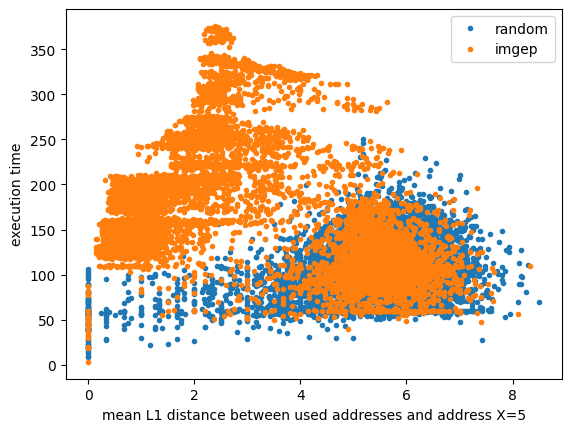

In [189]:
plt.figure()
plt.plot(mean_distance_to_address_program_rand,history_rand.memory_observation['time_core0'],'.',label="random")
plt.plot(mean_distance_to_address_program_imgep,history.memory_observation['time_core0'],'.',label="imgep")
plt.xlabel(f'mean L1 distance between used addresses and address X={address_x}')
plt.ylabel('execution time')
plt.legend()
plt.show()